# ECMWF Ensemble Precipitation Pipeline

This notebook demonstrates the precipitation download pipeline: ECMWF ENS `tp` (total precipitation) for all 51 members, stored as a compressed Zarr ZipStore.

## Overview

| Step | What happens |
|---|---|
| 1. Download `tp` | Parallel GRIB2 download for all 25 steps (0–144h at 6h intervals) and 51 members |
| 2. Build Zarr | Assemble into a single compressed ZipStore (`float16`, ~1.2 GB) |
| 3. Stage (optional) | Upload to Snowflake internal stage and insert metadata row |

**Key facts about the data:**
- `tp` is **accumulated** from T+0 — step 0 = 0 mm by definition
- Period totals are computed at read time: `data[member, step_b] - data[member, step_a]`
- Member 51 = HRES/control; members 1–50 = ENS perturbed — same numbering as `TC_TRACKS.ENSEMBLE_MEMBER`
- Zarr attribute `member_numbers` maps Zarr index → ECMWF member number explicitly

| Output file | Snowflake table | Shape |
|---|---|---|
| `tp_YYYYMMDD_HH.zarr.zip` | `PRECIP_FORECASTS` | (51 members, 25 steps, 481 lats, 1440 lons) |

## Setup

In [8]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

from ecmwf_met_downloader import download_ensemble_param
from visualization import show_precip_ensemble_mean, show_precip_period_panels, show_precip_exceedance

In [9]:
# ── Date / run-time selection ──────────────────────────────────────────────
#
# ECMWF publishes four ENS runs per day:
#   00Z  (published ~09:00 UTC)  →  144-hour precipitation horizon
#   06Z  (published ~13:00 UTC)  →  144-hour precipitation horizon
#   12Z  (published ~21:00 UTC)  →  144-hour precipitation horizon
#   18Z  (published ~01:00 UTC)  →  144-hour precipitation horizon
#
# ECMWF open data is only available for the last ~30 days.
# Use a recent date — older dates will return 404 errors on all steps.
#
# Use the same date and run time as the TC track notebook to enable track overlay.

SELECTED_DATE    = "20260703"   # "YYYYMMDD" — must be within the last ~30 days
SELECTED_RUNTIME = "00"         # "00" / "06" / "12" / "18"

# ── Visualization settings ─────────────────────────────────────────────────
PRECIP_STEP_H       = 72    # forecast hour for ensemble mean and exceedance maps (0–144)
PRECIP_THRESHOLD_MM = 50    # mm threshold for exceedance probability map

# ── Optional TC track overlay ──────────────────────────────────────────────
# Set to a path like 'tc_transformed/BERYL/..._transformed.csv' to overlay TC tracks,
# or leave as None to show precipitation maps without track overlay.
TC_TRACK_CSV = None

# Output directory
MET_DIR = Path('met_data')
MET_DIR.mkdir(exist_ok=True)

print(f"Target: {SELECTED_DATE} {SELECTED_RUNTIME}Z")

Target: 20260703 00Z


## Step 1: Download Total Precipitation

Downloads all 25 time steps (0–144h, 6-hourly) in parallel. Each step is a ~35–48 MB GRIB2 file
containing all 51 ensemble members. The full download is roughly 1 GB of GRIB2 that gets assembled
into a ~1.2 GB `float16` Zarr ZipStore.

In [10]:
# Normalise date and build the expected output path
d           = SELECTED_DATE.replace('-', '')
precip_date = f"{d[:4]}-{d[4:6]}-{d[6:]}"
zarr_path   = MET_DIR / f"tp_{d}_{int(SELECTED_RUNTIME):02d}.zarr.zip"

if zarr_path.exists():
    print(f"Found existing file — skipping download.")
else:
    precip_result = download_ensemble_param(
        param='tp',
        date=precip_date,
        run_time=int(SELECTED_RUNTIME),
        output_dir=str(MET_DIR),
        upload_to_stage=False,
        verbose=True,
    )
    if not precip_result['success']:
        raise RuntimeError(
            f"Download failed for {precip_date} {int(SELECTED_RUNTIME):02d}Z. "
            "ECMWF open data is only available for the last ~30 days — "
            "update SELECTED_DATE to a recent date."
        )
    zarr_path = precip_result['zip_path']

print(f"Zarr ZipStore : {zarr_path}")
print(f"File size     : {zarr_path.stat().st_size / 1e6:.0f} MB")

20260703000000-18h-enfo-ef.grib2:   0%|          | 0.00/37.8M [00:00<?, ?B/s]


20260703000000-18h-enfo-ef.grib2:   1%|          | 462k/37.8M [00:00<00:08, 4.38MB/s]


20260703000000-18h-enfo-ef.grib2:   4%|▍         | 1.55M/37.8M [00:00<00:04, 8.26MB/s]


20260703000000-18h-enfo-ef.grib2:   7%|▋         | 2.61M/37.8M [00:00<00:04, 8.87MB/s]
20260703000000-18h-enfo-ef.grib2:   9%|▉         | 3.51M/37.8M [00:00<00:04, 8.98MB/s]


20260703000000-18h-enfo-ef.grib2:  12%|█▏        | 4.44M/37.8M [00:00<00:03, 9.18MB/s]




20260703000000-18h-enfo-ef.grib2:  15%|█▍        | 5.50M/37.8M [00:00<00:03, 9.54MB/s]
20260703000000-18h-enfo-ef.grib2:  17%|█▋        | 6.56M/37.8M [00:00<00:03, 9.30MB/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.



20260703000000-18h-enfo-ef.grib2:  21%|██        | 7.80M/37.8M [00:00<00:03, 10.3MB/s]
20260703000000-18h-enfo-ef.grib2:  23%|██▎       | 8.80M/37.8M [00:00<00:03, 10.1MB/s]
20260703000000-18h-enfo-ef.grib2:  26%|██▌       | 9.86M/37.8M [00:01<00:02, 10.0MB/s]
20260703000000-18h-enfo-ef.grib2:  29%|██▊       | 10.8M/37.8M [00:01<00:02, 9.88MB/s]


20260703000000-18h-enfo-ef.grib2:  32%|███▏      | 12.0M/37.8M [00:01<00:02, 10.3MB/s]


20260703000000-18h-enfo-ef.grib2:  34%|███▍      | 13.0M/37.8M [00:01<00:02, 10.2MB/s]


20260703000000-18h-enfo-ef.grib2:  37%|███▋      | 14.0M/37.8M [00:01<00:02, 10.3MB/s]




20260703000000-18h-enfo-ef.grib2:  40%|███▉      | 15.0M/37.8M [00:01<00:02, 9.98MB/s]


20260703000000-18h-enfo-ef.grib2:  42%|████▏     | 16.0M/37.8M [00:01<00:02, 9.71MB/s]


20260703000000-18h-enfo-ef.grib2:  45%|████▍     | 17.0M/37.8M [00:01<00:02, 9.40MB/s]
20260703000000-18h-enfo-ef.grib2:  47%|████▋     | 17.9M/37.8M [00:02<00:02, 8.34MB/s]




20260703000000-18h-enfo-

Zarr ZipStore : met_data/tp_20260703_00.zarr.zip
File size     : 1270 MB


## Inspect the Zarr File

Quick sanity check: shape, member numbering, and a sample of values to confirm the accumulation is correct.

In [11]:
import zarr

store = zarr.storage.ZipStore(str(zarr_path), mode='r')
root  = zarr.open_group(store=store, mode='r')
z     = root['data']
attrs = dict(root.attrs)

print("=== Zarr metadata ===")
print(f"  Shape          : {z.shape}  (members, steps, lat, lon)")
print(f"  Dtype          : {z.dtype}")
print(f"  Forecast date  : {attrs['forecast_date']} {attrs['run_time']:02d}Z")
print(f"  Steps (hours)  : {attrs['steps']}")
print(f"  member_numbers : {attrs['member_numbers']}")
print(f"  Lat range      : {attrs['lat_min']}° – {attrs['lat_max']}°")
print()
print("=== Data checks ===")
step0 = np.asarray(z[:, 0, 240, 720])   # all members, step 0, mid-point
print(f"  Step 0 values (all members, should be 0 mm) : {np.unique(step0)}")
ts = np.asarray(z[0, :, 240, 720])      # member 1 (index 0), time series
print(f"  Member 1 accumulation 0→144h (sample)       : {ts[[0,4,8,12,24]].tolist()}")
print(f"  Monotonic accumulation?                      : {all(ts[i+1] >= ts[i] - 0.01 for i in range(len(ts)-1))}")
store.close()

=== Zarr metadata ===
  Shape          : (51, 25, 481, 1440)  (members, steps, lat, lon)
  Dtype          : float16
  Forecast date  : 2026-07-03 00Z
  Steps (hours)  : [0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84, 90, 96, 102, 108, 114, 120, 126, 132, 138, 144]
  member_numbers : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
  Lat range      : -60.0° – 60.0°

=== Data checks ===
  Step 0 values (all members, should be 0 mm) : [0.]
  Member 1 accumulation 0→144h (sample)       : [0.0, 0.251708984375, 0.3203125, 0.6103515625, 1.0068359375]
  Monotonic accumulation?                      : True


## Visualizations

Three complementary views of the ensemble precipitation forecast.

- **Ensemble mean** — where the model collectively expects rain by `PRECIP_STEP_H`
- **Period panels** — daily breakdown showing when and where the heaviest rain is forecast
- **Exceedance probability** — fraction of members that accumulate more than `PRECIP_THRESHOLD_MM` mm

Set `TC_TRACK_CSV` in the Setup cell to overlay TC tracks on the maps.

PRECIPITATION — ENSEMBLE MEAN
  Step: 72h  |  Ensemble max mean: 452.9mm


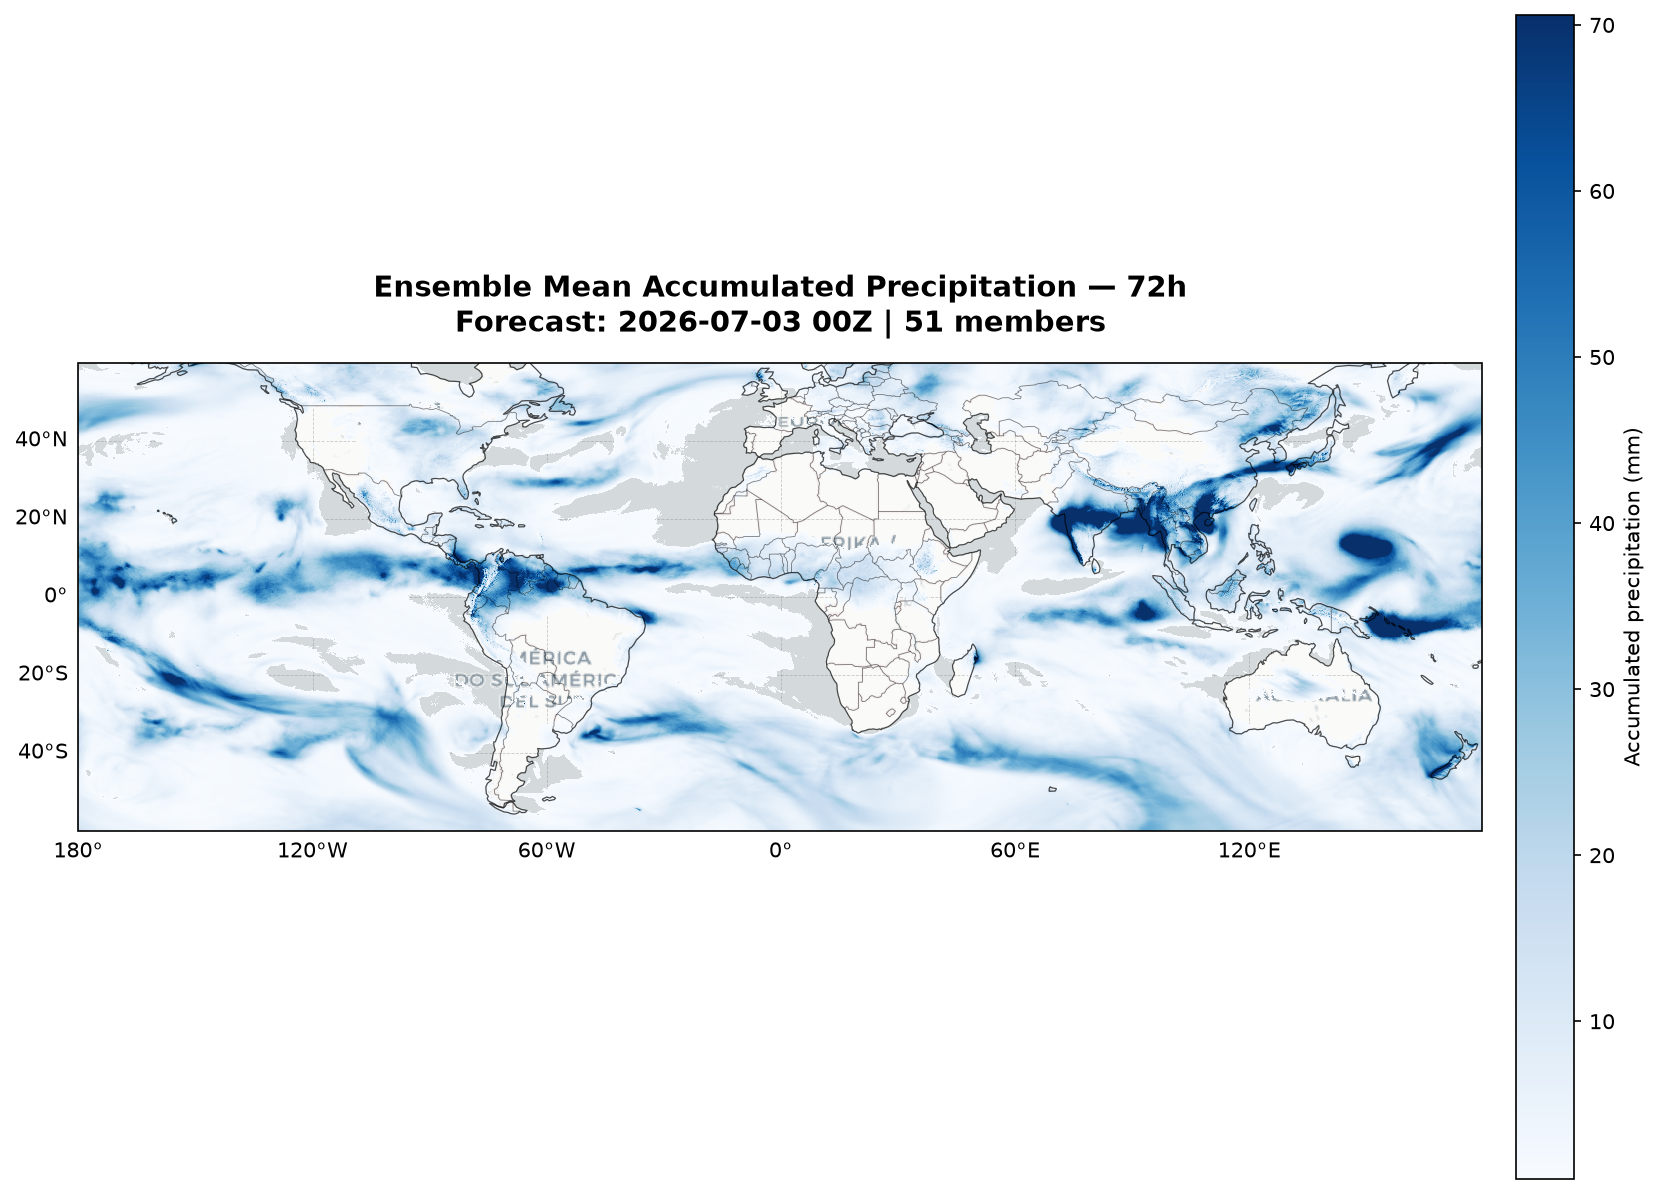

In [12]:
# Ensemble mean accumulated precipitation at PRECIP_STEP_H
show_precip_ensemble_mean(
    zarr_path,
    step_h=PRECIP_STEP_H,
    track_csv=TC_TRACK_CSV,
)

PRECIPITATION — PERIOD ACCUMULATION PANELS
    0– 24h: max 195.6mm
   24– 48h: max 230.8mm
   48– 72h: max 211.7mm
   72–144h: max 328.3mm


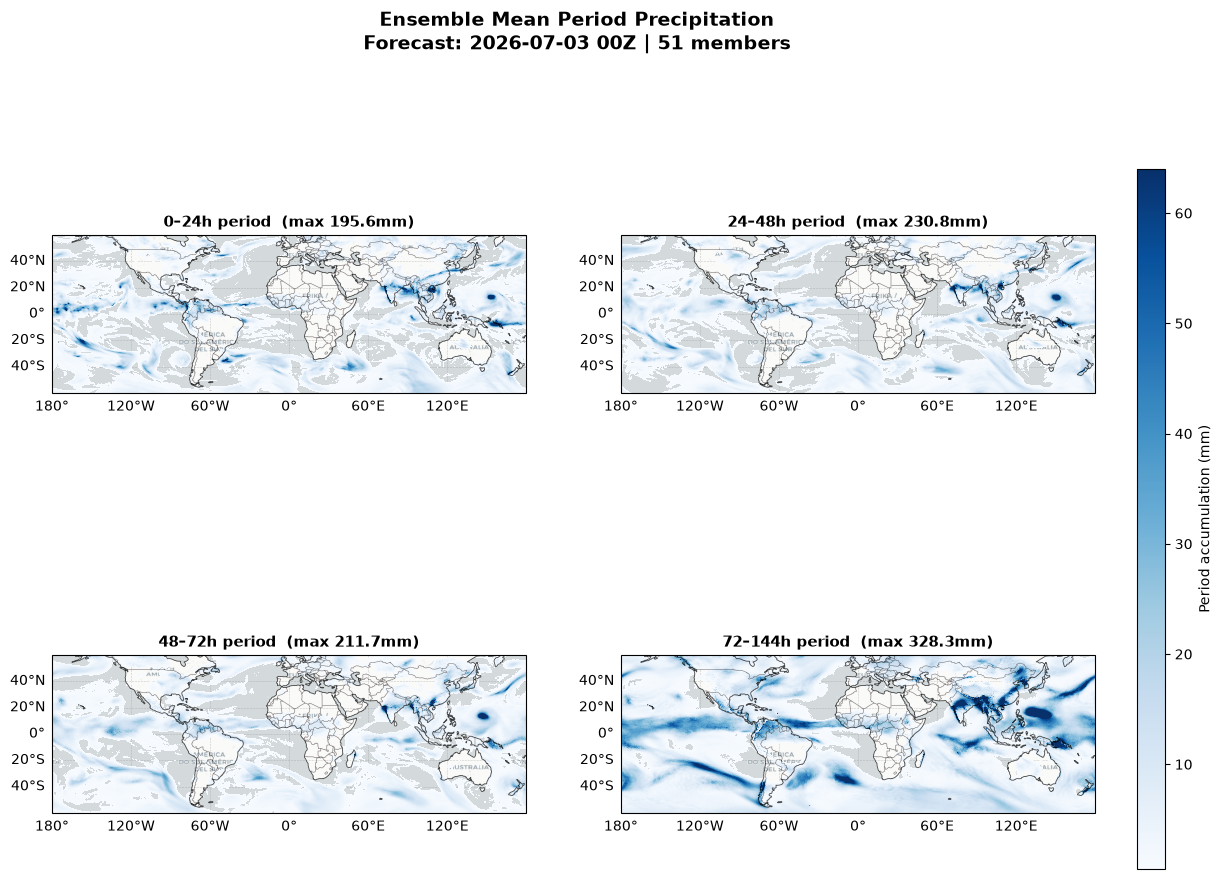

In [13]:
# 4-panel daily period accumulation: 0-24h, 24-48h, 48-72h, 72-144h
show_precip_period_panels(
    zarr_path,
    track_csv=TC_TRACK_CSV,
)

PRECIPITATION — EXCEEDANCE PROBABILITY (>50mm by 72h)
  Max exceedance probability : 100.0%
  Grid cells with P > 50%   : 14075


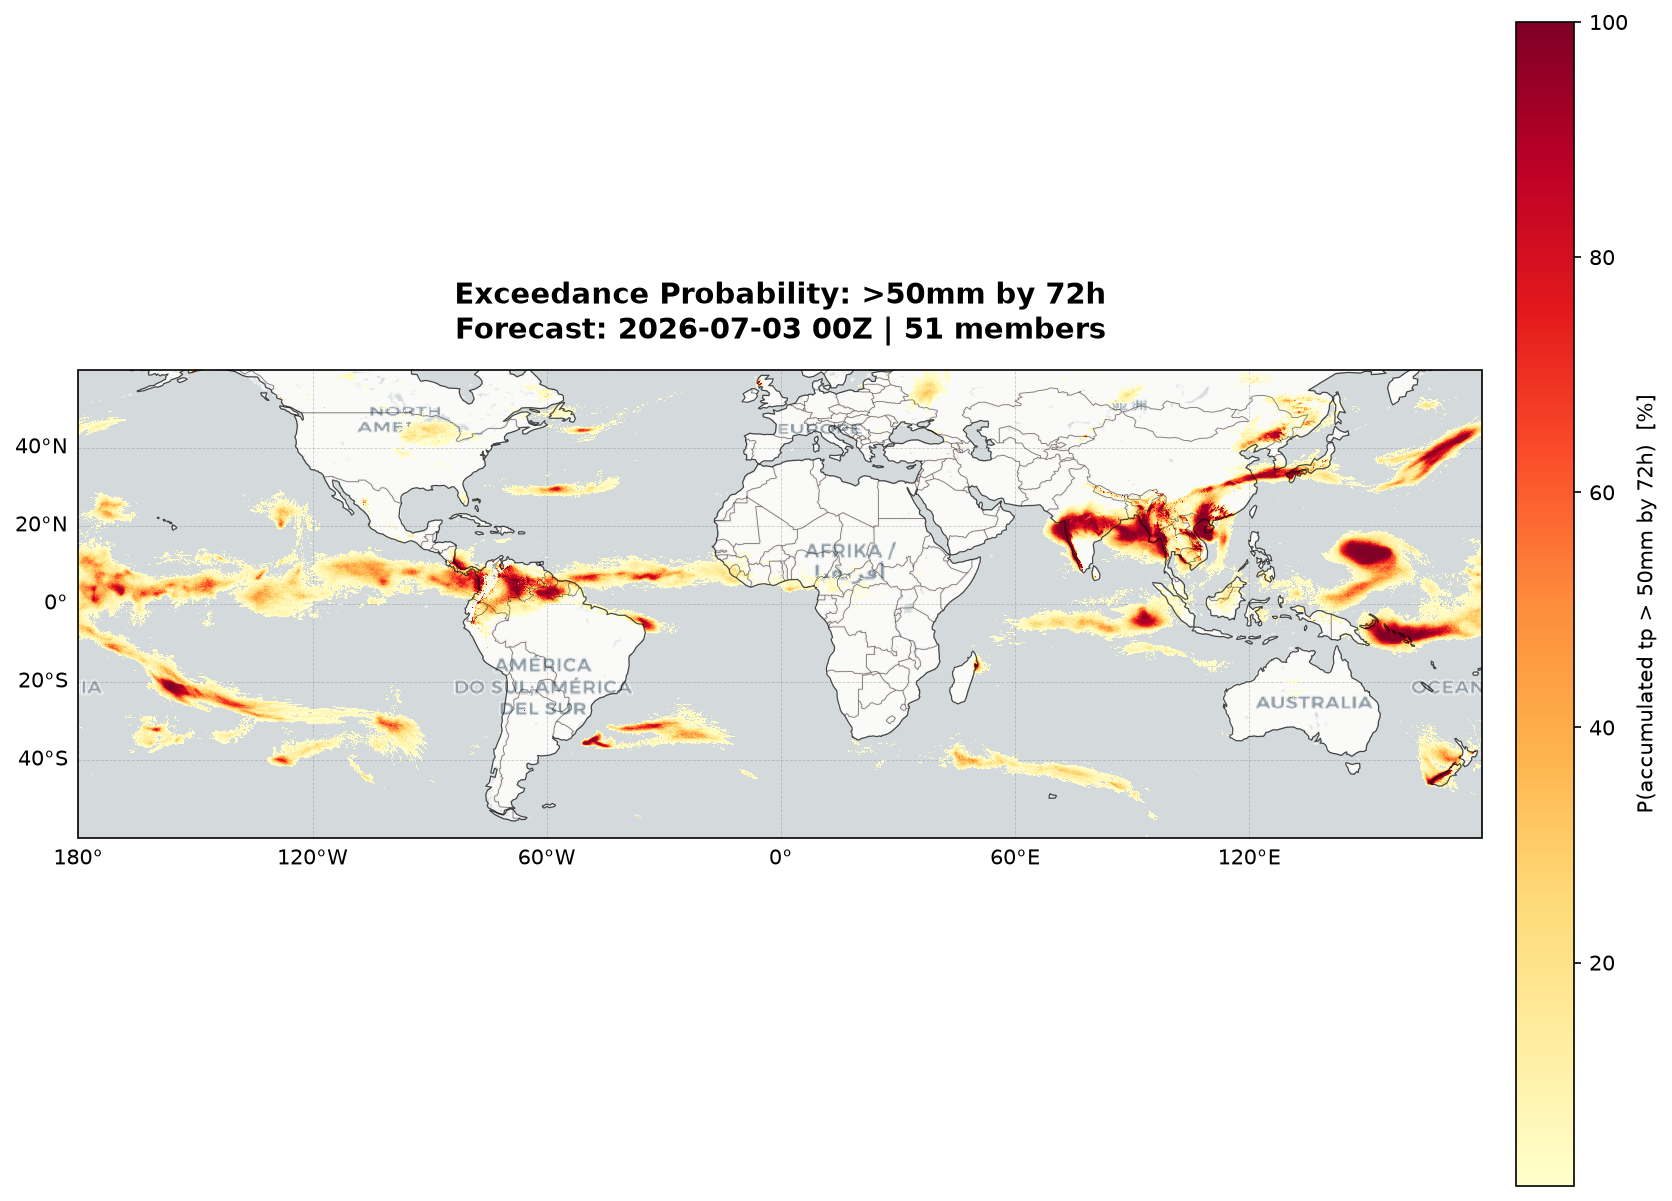

In [14]:
# Probability that accumulated tp exceeds PRECIP_THRESHOLD_MM mm by PRECIP_STEP_H
# Increase threshold_mm for intense TCs (e.g. 100mm or 200mm)
show_precip_exceedance(
    zarr_path,
    threshold_mm=PRECIP_THRESHOLD_MM,
    step_h=PRECIP_STEP_H,
    track_csv=TC_TRACK_CSV,
)